# Yt-QA-Agent

## System Architecture

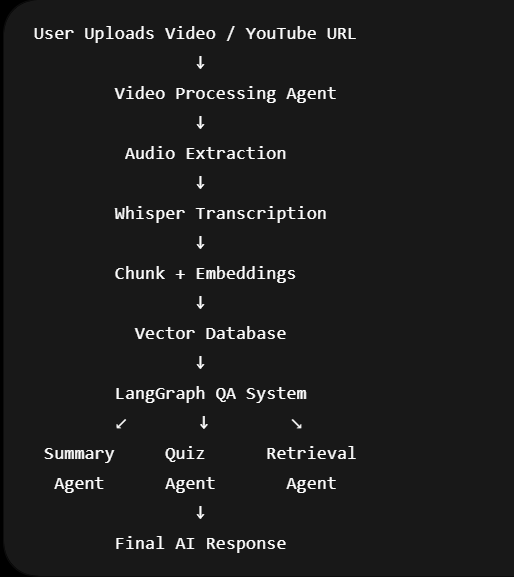

### Download YT Video

In [3]:
from yt_dlp import YoutubeDL
import os

#  folder creation 
try:
    directory_name = "downloaded_videos"
    if not os.path.exists(directory_name):
        os.makedirs(directory_name)  
    else:
        print(f"Directory '{directory_name}' already exists.")
except Exception as e:
    print(f"An error occurred while creating the directory: {e}")

def download_yt_video(url,output_path):
    yt_dlp = {
        "format":'mp4',
        "outtmpl": os.path.join(output_path, '%(title)s.%(ext)s'),
    }
    
    with YoutubeDL(yt_dlp) as ydl:
        info = ydl.extract_info(url, download=True)
        print(f"Video '{info['title']}' downloaded successfully.")
        
        return ydl.prepare_filename(info)
    

Directory 'downloaded_videos' already exists.


## Extract Audio from video

In [5]:
import ffmpeg
import  os

def extract_audio(video_path,output_path):
    
    try:
        directory_name = 'extracted_audios'
        if not os.path.exists(directory_name):
            os.makedirs(directory_name)
        else:
            print(f"Directory '{directory_name}' already exists.")
    except Exception as e:
        print(e)
        
    # get extracted audio
    
    audio_path = os.path.join(output_path, os.path.basename(video_path).split('.')[0] + '.mp3')
    return audio_path


## Hugging face comes into the picture

In [14]:
from huggingface_hub import login, logout
import os
hugging_face_api_key = os.getenv("HUGGINGFACE_API_KEY")

login()

## Transcription with Wishper

In [16]:
from faster_whisper import WhisperModel

# model definition 
model = WhisperModel("base",
                     device="cpu",
                     compute_type="int8")

def transcribe_audio(audio_path):
    segments,info = model.transcribe(audio_path, beam_size=5)
    
    transcript = []
    
    for segment in segments:
        transcript.append({
            "text":segment.text,
            "start":segment.start,
            "end":segment.end
        })
    return transcript

## Model creation

In [17]:
from langchain_groq import ChatGroq
from dotenv import  load_dotenv

load_dotenv()

llm_model = ChatGroq(
    model="openai/gpt-oss-20b"
)